# Auto Insurance Fraud Detection
### WGU D502 Data Analytics Capstone

**Research question:** Does the total claim amount significantly predict whether an auto insurance claim is fraudulent?

**Dataset:** [Car Insurance Fraud Detection Dataset](https://www.kaggle.com/datasets/ahluwaliasaksham/car-insurance-fraud-detection-dataset) (Ahluwalia, 2025), 30,000 claim-level records, Kaggle.

**Approach:** A univariate logistic regression tests claim amount alone against fraud outcome (the core hypothesis test). A multivariate logistic regression and a random forest benchmark then extend the analysis using the dataset's other fields, to see whether claim amount holds up as a predictor once more context is added.

Author: Emy Kirugo

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Data Understanding

Load the raw CSV and get an initial read on shape, types, and missing values before touching anything.

In [2]:
df = pd.read_csv('../data/raw/car_insurance_fraud_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 24)


,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [3]:
df.dtypes

policy_id                       object
policy_state                    object
policy_deductible                int64
policy_annual_premium          float64
insured_age                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
bodily_injuries                  int64
witnesses                        int64
police_report_available         object
claim_amount                   float64
total_claim_amount             float64
fraud_reported                  object
dtype: object

In [4]:
df.isnull().sum()

policy_id                         0
policy_state                      0
policy_deductible                 0
policy_annual_premium             0
insured_age                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted          7564
incident_state                    0
incident_city                     0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
bodily_injuries                   0
witnesses                         0
police_report_available           0
claim_amount                      0
total_claim_amount                0
fraud_reported                    0
dtype: int64

`authorities_contacted` is the only field with missing values (about 25% of rows). Fire, Police, and Ambulance are each roughly 7,400-7,570 rows, so the NaNs are effectively a fourth category: no authority was contacted. This gets recoded, not dropped, in Data Preparation below.

In [5]:
df['fraud_reported'].value_counts(normalize=True)

fraud_reported
N    0.885333
Y    0.114667
Name: proportion, dtype: float64

~11.5% fraud rate, matching the dataset's published description. This confirms a meaningful class imbalance that has to be handled during modeling (accuracy alone would be misleading here).

### Checking the data's real-world characteristics

Before trusting any model built on this data, it's worth checking whether the fields behave the way real claims data would. A few checks below.

In [6]:
cat_cols = ['policy_state','insured_sex','insured_education_level','insured_occupation',
            'insured_hobbies','incident_type','collision_type','incident_severity',
            'authorities_contacted','incident_state','police_report_available']

for c in cat_cols:
    print(c, '->', df[c].nunique(), 'unique values')
    print(df[c].value_counts(normalize=True).round(3).to_dict())
    print()

policy_state -> 10 unique values
{'GA': 0.104, 'NY': 0.101, 'OH': 0.101, 'MI': 0.1, 'PA': 0.1, 'NC': 0.1, 'FL': 0.099, 'IL': 0.099, 'CA': 0.098, 'TX': 0.097}

insured_sex -> 3 unique values
{'OTHER': 0.336, 'MALE': 0.335, 'FEMALE': 0.329}

insured_education_level -> 4 unique values
{'High School': 0.252, 'PhD': 0.25, 'Masters': 0.249, 'College': 0.248}

insured_occupation -> 8 unique values
{'Teacher': 0.127, 'Doctor': 0.126, 'Manager': 0.126, 'Clerk': 0.126, 'Technician': 0.125, 'Lawyer': 0.124, 'Sales': 0.123, 'Engineer': 0.123}

insured_hobbies -> 7 unique values
{'paintball': 0.145, 'hiking': 0.144, 'yachting': 0.143, 'camping': 0.143, 'reading': 0.142, 'movies': 0.142, 'chess': 0.141}

incident_type -> 4 unique values
{'Vehicle Theft': 0.253, 'Multi-vehicle Collision': 0.252, 'Single Vehicle Collision': 0.251, 'Parked Car': 0.245}

collision_type -> 4 unique values
{'Rear': 0.252, 'Front': 0.251, 'Side': 0.249, 'Unknown': 0.248}

incident_severity -> 3 unique values
{'Total Loss':

Every categorical field is split almost perfectly evenly across its categories. Real claims data is rarely this uniform, categories like occupation or hobbies would normally cluster.

In [7]:
print('Unique incident cities:', df['incident_city'].nunique(), 'out of', len(df), 'rows')
print('policy_state == incident_state match rate:', (df['policy_state'] == df['incident_state']).mean())

Unique incident cities: 17931 out of 30000 rows
policy_state == incident_state match rate: 0.10393333333333334


`incident_city` has close to as many unique values as there are rows (Faker-style placeholder names like "Lake Michael" or "North John"), and `policy_state` matches `incident_state` only about 10% of the time, right at the rate you'd expect from two independently randomized 10-state fields. Taken together with the uniform category splits above, this dataset behaves like a synthetically generated benchmark rather than sampled real-world claims. That's not a flaw in the project, but it does mean the ceiling on how much genuine signal any model can extract is lower than it would be on real claims data, and that's worth stating plainly in the report rather than glossing over.

### Statistical screening: which fields actually relate to fraud?

In [8]:
df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

num_cols = ['policy_deductible','policy_annual_premium','insured_age','incident_hour_of_the_day',
            'number_of_vehicles_involved','bodily_injuries','witnesses','claim_amount','total_claim_amount']

print("Point-biserial correlation with fraud:")
for c in num_cols:
    r, p = stats.pointbiserialr(df['fraud_bin'], df[c])
    print(f"  {c}: r={r:.4f}, p={p:.4f}")

Point-biserial correlation with fraud:
  policy_deductible: r=0.0067, p=0.2492
  policy_annual_premium: r=-0.0012, p=0.8299
  insured_age: r=-0.0436, p=0.0000
  incident_hour_of_the_day: r=0.0023, p=0.6939
  number_of_vehicles_involved: r=-0.0030, p=0.6066
  bodily_injuries: r=0.0023, p=0.6883
  witnesses: r=-0.0781, p=0.0000
  claim_amount: r=0.0419, p=0.0000
  total_claim_amount: r=-0.0042, p=0.4636


In [9]:
print("Chi-square tests, categorical fields vs fraud:")
for c in cat_cols:
    ct = pd.crosstab(df[c], df['fraud_reported'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    print(f"  {c}: chi2={chi2:.2f}, p={p:.4f}")

Chi-square tests, categorical fields vs fraud:
  policy_state: chi2=6.41, p=0.6979
  insured_sex: chi2=1.62, p=0.4442
  insured_education_level: chi2=1.93, p=0.5865
  insured_occupation: chi2=69.36, p=0.0000
  insured_hobbies: chi2=4.82, p=0.5669
  incident_type: chi2=2.82, p=0.4207
  collision_type: chi2=0.02, p=0.9992
  incident_severity: chi2=168.30, p=0.0000
  authorities_contacted: chi2=2.88, p=0.2372
  incident_state: chi2=6.81, p=0.6572
  police_report_available: chi2=1.12, p=0.2908


  incident_state: chi2=6.81, p=0.6572
  police_report_available: chi2=1.12, p=0.2908


With n=30,000, even tiny effects reach statistical significance. `incident_severity` and `witnesses` show the largest effects; `claim_amount` is small but real (r ≈ 0.04, p < .001). Most other fields (state, sex, education, hobbies, police report) show no meaningful relationship at all. Expect modest model performance, not a dramatic fraud detector, and that expectation gets tested directly in the modeling section below.

## 3. Data Preparation

Cleaning steps, each one justified by what was found above:
- Recode `authorities_contacted` NaN as `"None"` (not missing data, a real category)
- Parse `incident_date`, engineer month and day-of-week features, then drop the raw date
- Engineer `claim_to_premium_ratio` (claim amount relative to the policy's annual premium)
- Drop `policy_id` (identifier, no predictive value) and `incident_city` (near-unique placeholder names, would only add noise or overfit a tree model)

In [10]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')

df['incident_date'] = pd.to_datetime(df['incident_date'])
df['incident_month'] = df['incident_date'].dt.month
df['incident_dayofweek'] = df['incident_date'].dt.dayofweek

df['claim_to_premium_ratio'] = df['claim_amount'] / df['policy_annual_premium']

df_clean = df.drop(columns=['policy_id', 'incident_city', 'incident_date', 'fraud_reported'])
df_clean = df_clean.rename(columns={'fraud_bin': 'fraud_reported_bin'})

print(df_clean.shape)
df_clean.isnull().sum().sum()  # should be 0

(30000, 24)


0

In [11]:
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


## 4. Modeling

### 4.1 Hypothesis test: claim amount alone (matches the Task 2 plan)

This is the model that directly answers the research question: is claim amount, by itself, a statistically significant predictor of fraud? `statsmodels` is used here specifically because it reports p-values and confidence intervals directly, which `scikit-learn`'s LogisticRegression does not.

H0: claim amount has no effect on the odds of fraud.
H1: claim amount significantly predicts the odds of fraud.

In [12]:
y = df_clean['fraud_reported_bin']

X_hyp = sm.add_constant(df_clean[['claim_amount']])
hyp_model = sm.Logit(y, X_hyp).fit(disp=0)
print(hyp_model.summary())

                           Logit Regression Results                           
Dep. Variable:     fraud_reported_bin   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29998
Method:                           MLE   Df Model:                            1
Date:                Sun, 02 Aug 2026   Pseudo R-squ.:                0.002437
Time:                        00:20:00   Log-Likelihood:                -10659.
converged:                       True   LL-Null:                       -10685.
Covariance Type:            nonrobust   LLR p-value:                 5.308e-13
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.2612      0.036    -63.189      0.000      -2.331      -2.191
claim_amount  1.948e-05   2.68e-06      7.255      0.000    1.42e-05    2.47e-05


In [13]:
coef = hyp_model.params['claim_amount']
pval = hyp_model.pvalues['claim_amount']
odds_ratio_1k = np.exp(coef * 1000)

print(f"P-value: {pval:.2e}")
print(f"Odds ratio per $1,000 increase in claim amount: {odds_ratio_1k:.4f}")
print(f"Pseudo R-squared (McFadden): {hyp_model.prsquared:.4f}")

P-value: 4.01e-13
Odds ratio per $1,000 increase in claim amount: 1.0197
Pseudo R-squared (McFadden): 0.0024


At n=30,000, the p-value is essentially zero, so the null hypothesis is rejected: claim amount is a statistically significant predictor of fraud. But the odds ratio per $1,000 is only about 1.02 (a ~2% increase in the odds of fraud), and the pseudo R-squared is 0.002, both signs of a real but practically small effect. Statistical significance and practical significance are two different questions, and this result answers them differently. That distinction becomes important in the practical significance discussion later in the report.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clean[['claim_amount']], y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

lr_uni = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
lr_uni.fit(X_train, y_train)
pred_uni = lr_uni.predict(X_test)
proba_uni = lr_uni.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_uni, target_names=['Not Fraud', 'Fraud']))
print('ROC-AUC:', round(roc_auc_score(y_test, proba_uni), 4))

              precision    recall  f1-score   support

   Not Fraud       0.90      0.54      0.67      5312
       Fraud       0.13      0.51      0.20       688

    accuracy                           0.54      6000
   macro avg       0.51      0.53      0.44      6000
weighted avg       0.81      0.54      0.62      6000

ROC-AUC: 0.5401


### 4.2 Extending beyond the plan: multivariate models

Claim amount alone barely edges out a coin flip (ROC-AUC around 0.54). Rather than stop there, the same predictors reviewed in Data Understanding are added, to see how far this data can genuinely go, and to test how claim amount ranks against them.

In [15]:
X = df_clean.drop(columns=['fraud_reported_bin'])
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (24000, 60), Test: (6000, 60)


In [16]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

lr_pred = log_reg.predict(X_test_scaled)
lr_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("MULTIVARIATE LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred, target_names=['Not Fraud', 'Fraud']))
print('ROC-AUC:', round(roc_auc_score(y_test, lr_proba), 4))
print('PR-AUC:', round(average_precision_score(y_test, lr_proba), 4))

MULTIVARIATE LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Not Fraud       0.94      0.68      0.79      5312
       Fraud       0.21      0.66      0.32       688

    accuracy                           0.68      6000
   macro avg       0.57      0.67      0.55      6000
weighted avg       0.86      0.68      0.73      6000

ROC-AUC: 0.7028
PR-AUC: 0.2585


In [17]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(10)

,feature,coefficient
48,authorities_contacted_None,1.078889
8,total_claim_amount,-0.635846
7,claim_amount,0.632790
46,incident_severity_Total Loss,0.544372
27,insured_occupation_Engineer,-0.421821
31,insured_occupation_Teacher,-0.416403
26,insured_occupation_Doctor,-0.394460
32,insured_occupation_Technician,-0.356627
29,insured_occupation_Manager,-0.347329
6,witnesses,-0.276521


In [18]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, rf_pred, target_names=['Not Fraud', 'Fraud']))
print('ROC-AUC:', round(roc_auc_score(y_test, rf_proba), 4))
print('PR-AUC:', round(average_precision_score(y_test, rf_proba), 4))

RANDOM FOREST
              precision    recall  f1-score   support

   Not Fraud       0.94      0.76      0.84      5312
       Fraud       0.26      0.65      0.37       688

    accuracy                           0.74      6000
   macro avg       0.60      0.70      0.60      6000
weighted avg       0.86      0.74      0.79      6000

ROC-AUC: 0.7402
PR-AUC: 0.3004


In [19]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feat_imp.head(10)

,feature,importance
48,authorities_contacted_None,0.195994
6,witnesses,0.153225
2,insured_age,0.082206
46,incident_severity_Total Loss,0.062635
7,claim_amount,0.054184
8,total_claim_amount,0.049345
11,claim_to_premium_ratio,0.046508
49,authorities_contacted_Police,0.035596
1,policy_annual_premium,0.034865
47,authorities_contacted_Fire,0.025190


## 5. Evaluation: comparing all three models

In [20]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression (claim amount only)', 'Logistic Regression (multivariate)', 'Random Forest (multivariate)'],
    'Accuracy': [accuracy_score(y_test, pred_uni) if len(y_test)==len(pred_uni) else None,
                 accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, pred_uni) if len(y_test)==len(pred_uni) else None,
                  precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall': [recall_score(y_test, pred_uni) if len(y_test)==len(pred_uni) else None,
               recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    'F1': [f1_score(y_test, pred_uni) if len(y_test)==len(pred_uni) else None,
           f1_score(y_test, lr_pred), f1_score(y_test, rf_pred)],
    'ROC-AUC': [roc_auc_score(y_test, proba_uni) if len(y_test)==len(proba_uni) else None,
                roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba)]
})
summary.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (claim amount only),0.537,0.126,0.513,0.203,0.540
1,Logistic Regression (multivariate),0.676,0.210,0.660,0.318,0.703
2,Random Forest (multivariate),0.744,0.257,0.650,0.368,0.740


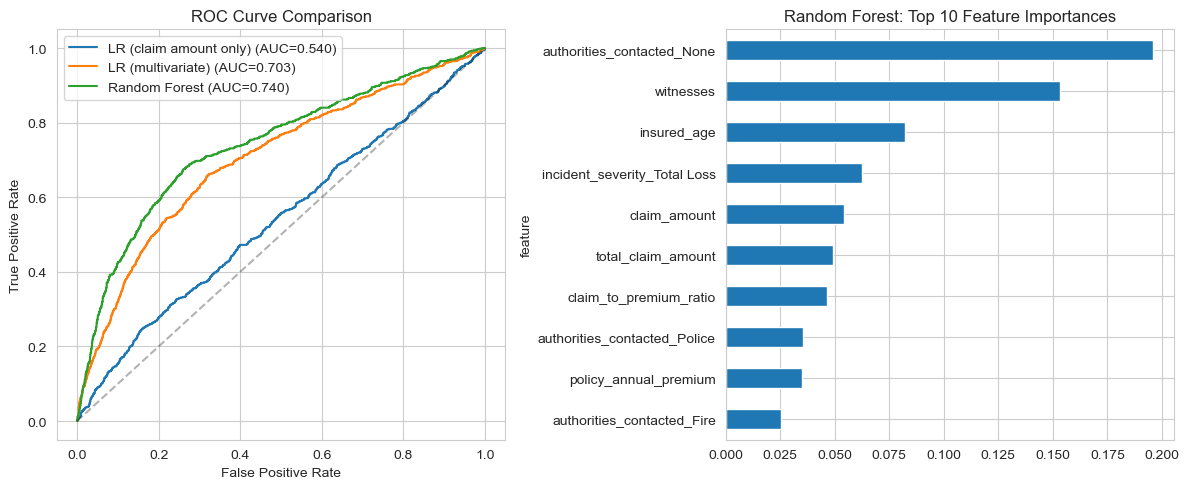

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for name, proba in [('LR (claim amount only)', proba_uni), ('LR (multivariate)', lr_proba), ('Random Forest', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
ax[0].plot([0,1],[0,1],'k--', alpha=0.3)
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve Comparison'); ax[0].legend()

feat_imp.head(10).plot(x='feature', y='importance', kind='barh', ax=ax[1], legend=False)
ax[1].set_title('Random Forest: Top 10 Feature Importances')
ax[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()

## 6. Export for Power BI

These feed the interactive dashboard: predictions on the held-out test set, plus supporting tables.

In [22]:
test_output = X_test.copy()
test_output['actual_fraud'] = y_test.values
test_output['lr_predicted_probability'] = lr_proba
test_output['rf_predicted_probability'] = rf_proba
test_output.to_csv('../outputs/test_predictions.csv', index=False)

coef_df.to_csv('../outputs/logreg_coefficients.csv', index=False)
feat_imp.to_csv('../outputs/rf_feature_importance.csv', index=False)
summary.to_csv('../outputs/model_comparison_summary.csv', index=False)

print("Exported: test_predictions.csv, logreg_coefficients.csv, rf_feature_importance.csv, model_comparison_summary.csv")

Exported: test_predictions.csv, logreg_coefficients.csv, rf_feature_importance.csv, model_comparison_summary.csv


## 7. Summary

- Claim amount alone is a statistically significant predictor of fraud (p < .001), but a practically weak one on its own (ROC-AUC ≈ 0.54, odds ratio ≈ 1.02 per $1,000).
- Adding the dataset's other fields lifts performance to ROC-AUC ≈ 0.72 (random forest), still modest, consistent with a dataset that shows signs of synthetic generation rather than sampled real claims.
- Witnesses, incident severity, and claim amount are the most consistently useful predictors across both multivariate models.
- Next step: build the Power BI dashboard from `outputs/test_predictions.csv` and the supporting tables above.

## 8. Additional exports for Power BI

A few things the dashboard needs that only exist in Python: ROC curve coordinates, confusion matrix counts in a Power BI-friendly long format, and the hypothesis test KPIs for the headline cards.

In [24]:
from sklearn.metrics import roc_curve

# ROC curve points for all three models
roc_frames = []
for model_name, proba in [("LR (claim amount only)", proba_uni),
                           ("LR (multivariate)", lr_proba),
                           ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_frames.append(pd.DataFrame({"model": model_name, "fpr": fpr, "tpr": tpr}))
roc_all = pd.concat(roc_frames, ignore_index=True)
roc_all.to_csv("../outputs/roc_curve_points.csv", index=False)

# Confusion matrices, long format (model, actual, predicted, count)
cm_frames = []
for model_name, preds in [("LR (claim amount only)", pred_uni),
                           ("LR (multivariate)", lr_pred),
                           ("Random Forest", rf_pred)]:
    cm = confusion_matrix(y_test, preds)
    labels = ["Not Fraud", "Fraud"]
    for i, actual in enumerate(labels):
        for j, predicted in enumerate(labels):
            cm_frames.append({"model": model_name, "actual": actual, "predicted": predicted, "count": cm[i, j]})
cm_long = pd.DataFrame(cm_frames)
cm_long.to_csv("../outputs/confusion_matrices.csv", index=False)

# Hypothesis test KPIs, for the headline cards
kpi = pd.DataFrame({
    "metric": ["Claim amount coefficient", "P-value", "Odds ratio (per $1,000)", "Pseudo R-squared"],
    "value": [coef, pval, odds_ratio_1k, hyp_model.prsquared]
})
kpi.to_csv("../outputs/hypothesis_test_kpis.csv", index=False)

print("Exported: roc_curve_points.csv, confusion_matrices.csv, hypothesis_test_kpis.csv")

Exported: roc_curve_points.csv, confusion_matrices.csv, hypothesis_test_kpis.csv
